# Imports

In [1]:
from pySVA.sva_core import *
from pySVA.sva_calc import *

In [2]:
import pandas as pd

In [3]:
from pySVA.sva_helpers import *

In [4]:
import dfm_tools as dfmt
import numpy as np
import xarray as xr

In [5]:
import pandas as pd

# Data description

In [24]:
# data_description = {
#     "nfaces": "mesh2d_nFaces",
#     "depth": "mesh2d_nLayers",
#     "time" : "time"
# }

data_description = {
    "flow_area": "mesh2d_au",
    "volume": "mesh2d_vol1",
    "velx" : "mesh2d_ucx",
    "vely" : "mesh2d_ucy",
    "velz" : "mesh2d_ucz",
    "viscosity" : "mesh2d_vicwwu",
    "tracer" : "mesh2d_sa1",
    "depth": "mesh2d_flowelem_zcc",
    "interfaces": "mesh2d_flowelem_zw"
}

In [25]:
import numpy as np

# Set up dask cluster

In [26]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

In [27]:
n_cores = 16
n_processes = 4
n_workers = n_cores/n_processes
mem_lim = str(336)+'GB' # str(int(np.floor(336/(n_workers))))+'GB' # 336 for genoa # 224 for rome #n_cores*

In [28]:
cluster = SLURMCluster(name='dask-cluster',
                       cores=n_cores,
                       memory=mem_lim,
                       processes=n_processes,
                       interface='ib0',
                       queue='genoa',
                       walltime='04:00:00',
                       asynchronous=0)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34193 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: tcp://172.22.63.190:44457
INFO:distributed.scheduler:  dashboard at:  http://172.22.63.190:34193/status
INFO:distributed.scheduler:Registering Worker plugin shuffle


In [29]:
print(cluster.job_script())

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p genoa
#SBATCH -n 1
#SBATCH --cpus-per-task=16
#SBATCH --mem=313G
#SBATCH -t 04:00:00

/home/mgeraeds/.conda/envs/dfm_proc_env/bin/python -m distributed.cli.dask_worker tcp://172.22.63.190:44457 --name dummy-name --nthreads 4 --memory-limit 78.23GiB --nworkers 4 --nanny --death-timeout 60 --interface ib0



In [30]:
cluster.scale(1)

In [31]:
client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-b3a5489f-0f01-11ef-99ae-00001029fe80
INFO:distributed.core:Starting established connection to tcp://172.22.63.190:55496


In [32]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.22.63.190:34193/status,
Dashboard: http://172.22.63.190:34193/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.22.63.190:44457,Workers: 0
Dashboard: http://172.22.63.190:34193/status,Total threads: 0
Started: Just now,Total memory: 0 B


INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.59.155:43143', name: dask-cluster-0-3, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.59.155:43143
INFO:distributed.core:Starting established connection to tcp://172.22.59.155:45132
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.59.155:44003', name: dask-cluster-0-2, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.59.155:44003
INFO:distributed.core:Starting established connection to tcp://172.22.59.155:45114
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.59.155:44187', name: dask-cluster-0-0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.59.155:44187
INFO:distributed.core:Starting established connection to tcp://172.22.59.155:45128
INFO:distributed.scheduler:Register worker <Worke

In [14]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/00_RMM3d_2022_simulations/computations/B02_2022_jul21-aug7/B02_2022_jul21-aug7_sm/RMM_dflowfm_2022_jul21_aug7_sm_000*_map.nc'

# Load dataset

In [43]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/B04/B04_2022_jun23-24/ZUNO-zd_dflowfm_B04_jun23-24_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/C01/C01_jul30-31/RMD_dflowfm_C01_jul30-31_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/D02/D02_t1/RMD_dflowfm_D02_t1_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AU/RMD_dflowfm_D02AU_0000_map.nc'
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/05_RMD_2019/computations/D02/D02AP/RMD_dflowfm_D02AP_0000_map.nc'

In [44]:
data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_*_"), chunks={'time':1})# "mesh2d_nFaces":50000, "mesh2d_nNodes":50000, "mesh2d_nEdges":50000})#, "mesh2d_nFaces":5000, "mesh2d_nNodes":5000, "mesh2d_nEdges":5000})

>> xu.open_dataset() with 96 partition(s): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 

KeyboardInterrupt: 

INFO:distributed.core:Connection to tcp://172.22.59.155:45128 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.59.155:44187', name: dask-cluster-0-0, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715371371.7697208')
INFO:distributed.core:Connection to tcp://172.22.59.155:45132 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.59.155:43143', name: dask-cluster-0-3, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715371371.7722914')
INFO:distributed.core:Connection to tcp://172.22.59.155:45114 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.59.155:44003', name: dask-cluster-0-2, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715371371.774994')
INFO:distributed.batched:Batched Comm Closed <TCP (closed) Scheduler connection to worker local=tcp://172.22.63.190:44457 remote=tcp://172.22.5

In [41]:
uds = data_xr

In [18]:
uds.ugrid.set_crs("EPSG:28992")
uds = uds.ugrid.to_crs('WGS84')

In [42]:
uds

<xarray.Dataset>
Dimensions:                      (time: 47, mesh2d_nNodes: 133336,
                                  mesh2d_nFaces: 126438, mesh2d_nLayers: 36,
                                  mesh2d_nInterfaces: 37, Two: 2,
                                  mesh2d_nEdges: 259786)
Coordinates:
  * time                         (time) datetime64[ns] 2019-07-30T12:00:00 .....
    mesh2d_node_x                (mesh2d_nNodes) float64 dask.array<chunksize=(1394,), meta=np.ndarray>
    mesh2d_node_y                (mesh2d_nNodes) float64 dask.array<chunksize=(1394,), meta=np.ndarray>
    mesh2d_face_x                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_face_y                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_zcc          (time, mesh2d_nFaces, mesh2d_nLayers) float32 dask.array<chunksize=(1, 1315, 36), meta=np.ndarray>
    mesh2d_flowelem_zw           (time, mesh2d_nFaces, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 1315, 37), meta=np.ndarray>
    mesh2d_edge_x                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
    mesh2d_edge_y                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
  * mesh2d_nFaces                (mesh2d_nFaces) int64 0 1 2 ... 126436 126437
  * mesh2d_nNodes                (mesh2d_nNodes) int64 0 1 2 ... 133334 133335
  * mesh2d_nEdges                (mesh2d_nEdges) int64 0 1 2 ... 259784 259785
Dimensions without coordinates: mesh2d_nLayers, mesh2d_nInterfaces, Two
Data variables: (12/42)
    projected_coordinate_system  int32 ...
    timestep                     (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    mesh2d_node_z                (mesh2d_nNodes) float64 dask.array<chunksize=(1394,), meta=np.ndarray>
    mesh2d_bldepth               (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_ba           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_bl           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    ...                           ...
    mesh2d_windxu                (time, mesh2d_nEdges) float32 dask.array<chunksize=(1, 2708), meta=np.ndarray>
    mesh2d_windyu                (time, mesh2d_nEdges) float32 dask.array<chunksize=(1, 2708), meta=np.ndarray>
    mesh2d_turkin1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_vicwwu                (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_tureps1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_cftrt                 (time, mesh2d_nEdges) float32 dask.array<chunksize=(1, 2708), meta=np.ndarray>
Attributes:
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.4a31aea51d1d200d4eb2f3262c80...
    history:                   Created on 2024-05-10T11:24:46+0200, D-Flow FM
    date_created:              2024-05-10T11:24:46+0200
    date_modified:             2024-05-10T11:24:46+0200
    Conventions:               CF-1.8 UGRID-1.0 Deltares-0.10 ACDD-1.3
    uuid:                      8230704e-c661-4fe5-add2-6901c22c853f
    time_coverage_start:       2019-08-01T01:10:00+00:00
    time_coverage_end:         2019-08-01T16:00:00+00:00
    time_coverage_duration:    P0000-00-00T14:50:00
    time_coverage_resolution:  P0000-00-00T00:20:00

In [19]:
gridname = uds.grid.name

In [20]:
uds.ugrid.crs[f'{gridname}'].name == 'WGS 84'

True

In [21]:
uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_flowelem_bl'] < 0, np.nan)

In [22]:
uds['mesh2d_sa1'] = uds['mesh2d_sa1'].where(uds['mesh2d_sa1'] < 35, np.nan)


In [23]:
import xugrid as xu
import matplotlib.pyplot as plt

In [24]:
sva_obj = constructorSVA(uds, data_description)

In [25]:
from dfmproc.utils.plotting import GeneralPlot, plot_basic_background

In [26]:
import cmocean.cm as cmo
import cmestuary.cm as cme

In [27]:
dimn_cart = f'mesh2d_nCartesian_coords'

In [28]:
bool_drycells = (uds['mesh2d_s1'] - uds['mesh2d_flowelem_bl']) < 0.25 # 0.0001 # standard EPSHU #other option: 0.0025
# bool_drycells = (uds['mesh2d_flowelem_bl'] > 0)

In [29]:
import matplotlib as mpl

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

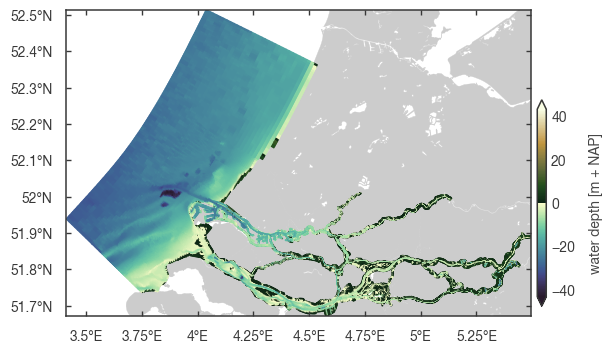

In [30]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = uds['mesh2d_flowelem_bl'].ugrid.plot(cmap=cmo.topo, add_labels=False, add_colorbar=False)
# pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"water depth [m + NAP]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

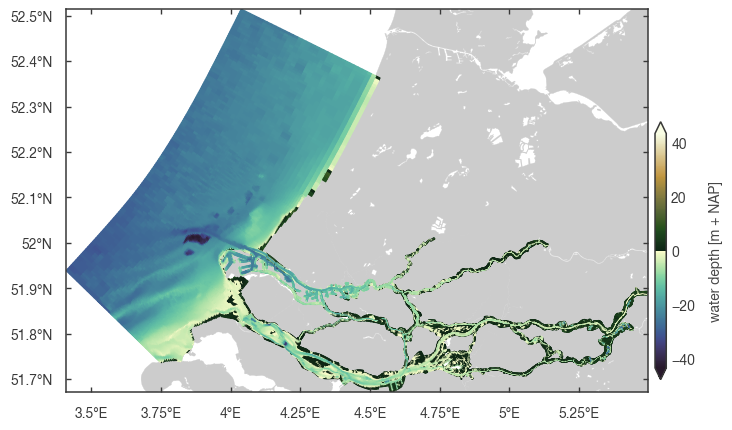

INFO:distributed.core:Connection to tcp://172.22.60.104:58882 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.60.104:35599', name: dask-cluster-0-1, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715175352.5385594')
INFO:distributed.core:Connection to tcp://172.22.60.104:58898 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.60.104:39279', name: dask-cluster-0-2, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715175352.6076558')
INFO:distributed.core:Connection to tcp://172.22.60.104:58880 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.60.104:33063', name: dask-cluster-0-0, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715175352.6091409')
INFO:distributed.batched:Batched Comm Closed <TCP (closed) Scheduler connection to worker local=tcp://172.22.63.190:40447 remote=tcp://172.22.

In [34]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(7.5, 6.25))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = uds['mesh2d_flowelem_bl'].ugrid.plot(cmap=cmo.topo, add_labels=False, add_colorbar=False)
# pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"water depth [m + NAP]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 
plt.savefig(r'rmd_bathymetry.pdf', format='pdf', bbox_inches="tight")

In [37]:
ucx_grad = sva_obj.compute_gradient_on_face(sva_obj.velx)
ucy_grad = sva_obj.compute_gradient_on_face(sva_obj.vely)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 13.86 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163

In [38]:
div = ucy_grad.isel(mesh2d_nCartesian_coords=1) + ucx_grad.isel(mesh2d_nCartesian_coords=0)

In [39]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

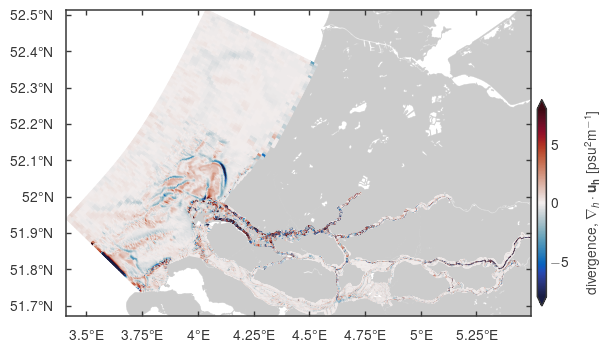

In [42]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = (div/f).isel(mesh2d_nLayers=35, time=10).ugrid.plot(vmin=-8, vmax=8, cmap=cmo.balance, add_labels=False, add_colorbar=False)
# pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"divergence, $\nabla_h \cdot \mathbf{u_h}$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 

In [43]:
straining = sva_obj.straining

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 13.86 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163

In [47]:
import matplotlib.colors as mcolors

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

0.25


TypeError: unsupported operand type(s) for *: 'int' and 'NoneType'

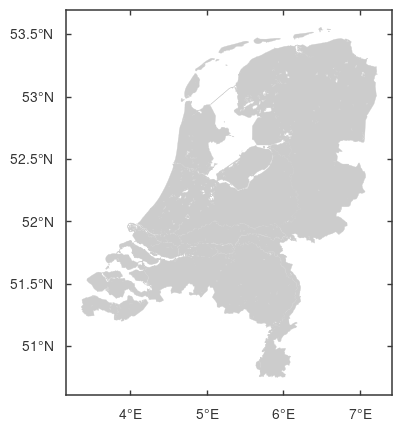

INFO:distributed.core:Connection to tcp://172.22.59.242:38736 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.59.242:46807', name: dask-cluster-0-1, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715100263.3988001')
INFO:distributed.core:Connection to tcp://172.22.59.242:38744 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.59.242:43623', name: dask-cluster-0-2, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715100263.6625242')
INFO:distributed.core:Connection to tcp://172.22.59.242:38728 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://172.22.59.242:46351', name: dask-cluster-0-3, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1715100263.6643171')
INFO:distributed.batched:Batched Comm Closed <TCP (closed) Scheduler connection to worker local=tcp://172.22.63.192:45667 remote=tcp://172.22.

In [59]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = straining.isel(time=10).ugrid.plot(cmap=cme.variance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5), vmin=-1, vmax=1)
# pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"straining, $\int -2u'_{v} s'_{v} \cdot \nabla \bar{s} dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
# cb.ax.tick_params(labelsize=9) 

In [45]:
dissipation = sva_obj.dissipation

edge-to-face interpolation: 

0.32 sec


In [46]:
advection = sva_obj.advection

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 13.86 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163

In [73]:
from matplotlib import ticker

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

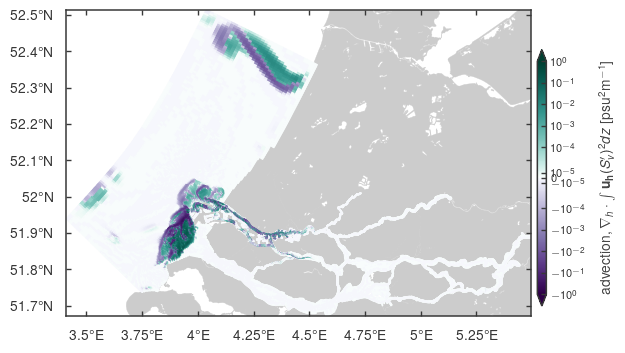

In [79]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)
pc = advection.isel(time=2).ugrid.plot(vmin=-1, vmax=1, cmap=cme.variance, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5))

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.1])
# cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r"advection, $\nabla_h \cdot \int\mathbf{u_h}(S'_{v})^2 dz$ [psu$^2$m$^{-1}$]"
cb.set_label(f'{tracer_string}', labelpad=10)
cb.ax.tick_params(labelsize=8)

In [65]:
import cmasher as cmr

In [66]:
cmap_sub = cmr.get_sub_cmap(cme.variance, 0, 0.5)

In [67]:
import matplotlib.colors as mcolors

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

(51.78, 52.28)

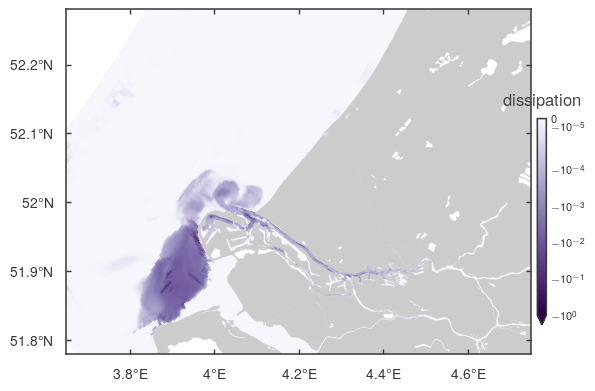

In [83]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
pc = dissipation.isel(time=2).ugrid.plot(vmin=-1, vmax=0, cmap=cmap_sub, add_labels=False, add_colorbar=False, norm=mcolors.SymLogNorm(linthresh=5e-5), zorder=0)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='min')
tracer_string = r"dissipation"#, $\nabla_h \cdot \int\mathbf{u_h}(S'_{v})^2 dz$ [psu$^2$m$^{-1}$]"
# cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.set_title(f'{tracer_string}')
cb.ax.tick_params(labelsize=8) 
ax.set_xlim(3.65, 4.75)
ax.set_ylim(51.78, 52.28)

In [37]:
# t = '2022/06/23 02:30'
# fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(4,3))
# bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
# pc = (salinity_gradient*1000).isel(mesh2d_nLayers=45).sel(time=t).ugrid.sel(y=slice(51.8, 52.4), x=slice(3.6, 4.5)).ugrid.plot(ax=ax,add_labels=False, add_colorbar=False, vmax=5, zorder=0)

# # add colorbar
# cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.03, ax.get_position().height - 0.2])
# cax.tick_params(axis=u'both', which=u'both', length=0)

# # cbar limits + others
# ax.set_ylim(51.8, 52.35)
# ax.set_xlim(3.65, 4.45)
# cb = plt.colorbar(pc, cax=cax, extend='max')
# tracer_string = r'$|\nabla_h s|$ [psu/km]'
# cb.set_label(f'{tracer_string}', labelpad=10, fontsize=8)
# cb.ax.tick_params(labelsize=6) 
# ax.set_title(f'{t}, LW')
# # plt.savefig('fronts_LW.png', transparent=True)

In [66]:
import matplotlib as mpl

In [36]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

In [120]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='EPSG:28992', zorder=0)

pc=(div/f).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r'$\nabla\cdot\mathbf{u}$'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 

In [ ]:
gradient = sva_obj.compute_gradient_on_face(sva_obj.tracer)

In [47]:
salinity_gradient = np.sqrt(gradient.isel({dimn_cart:0})**2 + gradient.isel({dimn_cart:1})**2).where(~bool_drycells)

<xarray.Dataset>
Dimensions:                      (time: 13, mesh2d_nNodes: 133336,
                                  mesh2d_nFaces: 126438, mesh2d_nLayers: 36,
                                  mesh2d_nInterfaces: 37, Two: 2,
                                  mesh2d_nEdges: 259786,
                                  mesh2d_nCartesian_coords: 2)
Coordinates:
  * time                         (time) datetime64[ns] 2022-01-01T12:00:00 .....
    mesh2d_node_x                (mesh2d_nNodes) float64 4.252 4.253 ... 4.459
    mesh2d_node_y                (mesh2d_nNodes) float64 51.79 51.79 ... 51.89
    mesh2d_face_x                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_face_y                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_zcc          (time, mesh2d_nFaces, mesh2d_nLayers) float32 dask.array<chunksize=(1, 1315, 36), meta=np.ndarray>
    mesh2d_flowelem_zw           (time, mesh2d_nFaces, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 1315, 37), meta=np.ndarray>
    mesh2d_edge_x                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
    mesh2d_edge_y                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
  * mesh2d_nFaces                (mesh2d_nFaces) int64 0 1 2 ... 126436 126437
  * mesh2d_nEdges                (mesh2d_nEdges) int64 0 1 2 ... 259784 259785
  * mesh2d_nNodes                (mesh2d_nNodes) int64 0 1 2 ... 133334 133335
Dimensions without coordinates: mesh2d_nLayers, mesh2d_nInterfaces, Two,
                                mesh2d_nCartesian_coords
Data variables: (12/46)
    projected_coordinate_system  int32 ...
    timestep                     (time) float32 dask.array<chunksize=(1,), meta=np.ndarray>
    mesh2d_node_z                (mesh2d_nNodes) float64 dask.array<chunksize=(1394,), meta=np.ndarray>
    mesh2d_bldepth               (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_ba           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_bl           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    ...                           ...
    mesh2d_turkin1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_vicwwu                (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_tureps1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_cftrt                 (time, mesh2d_nEdges) float32 dask.array<chunksize=(1, 2708), meta=np.ndarray>
    mesh2d_dicwwu                (time, mesh2d_nEdges, mesh2d_nInterfaces) float32 dask.array<chunksize=(1, 2708, 37), meta=np.ndarray>
    mesh2d_unvs                  (mesh2d_nEdges, mesh2d_nCartesian_coords) float64 ...
Attributes:
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.4a31aea51d1d200d4eb2f3262c80...
    history:                   Created on 2024-05-02T16:15:43+0200, D-Flow FM
    date_created:              2024-05-02T16:15:43+0200
    date_modified:             2024-05-02T16:15:43+0200
    Conventions:               CF-1.8 UGRID-1.0 Deltares-0.10 ACDD-1.3
    uuid:                      203ecdd4-9b57-45fc-a456-b02b9058b80f
    time_coverage_start:       2022-01-01T12:00:00+00:00
    time_coverage_end:         2022-01-02T12:00:00+00:00
    time_coverage_duration:    P0000-00-01T00:00:00
    time_coverage_resolution:  P0000-00-00T02:00:00

INFO:distributed.utils_perf:full garbage collection released 11.25 MiB from 135046 reference cycles (threshold: 9.54 MiB)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 39.34 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.24s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


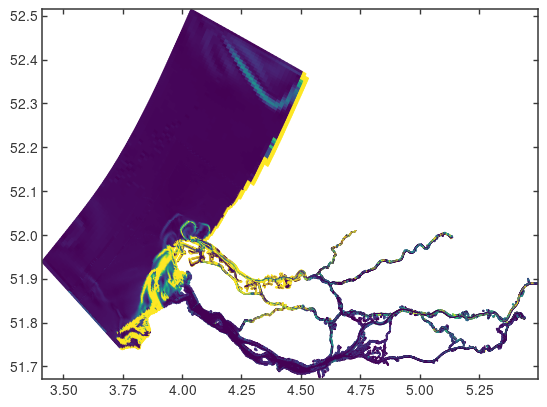

In [71]:
(salinity_gradient*1000).where(uds['mesh2d_flowelem_bl'] < -.5, np.nan).isel(mesh2d_nLayers=35, time=2).ugrid.plot(add_labels=False, add_colorbar=False, vmax=5, zorder=0)